In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub

warnings.filterwarnings('ignore') # لإخفاء أي تحذيرات مزعجة

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, SeparableConv2D, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Concatenate, BatchNormalization, Dense, Dropout, Reshape, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ثوابت المشروع
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 111
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
train_dir = os.path.join(dataset_path, 'Training')
test_dir = os.path.join(dataset_path, 'Testing')
print("✅ Dataset Ready!")

✅ Dataset Ready!


In [4]:
def get_data_labels(directory):
    paths, labels = [], []
    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)
        if not os.path.isdir(label_dir): continue
        for image in os.listdir(label_dir):
            paths.append(os.path.join(label_dir, image))
            labels.append(label)
    return paths, labels

# جلب كل المسارات
train_paths_full, train_labels_full = get_data_labels(train_dir)
test_paths, test_labels = get_data_labels(test_dir)

# تقسيم التدريب لـ Train و Validation (85% - 15%)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_full, train_labels_full, test_size=0.15, stratify=train_labels_full, random_state=SEED
)

# تحويلهم لـ DataFrames
train_df = pd.DataFrame({'filepath': train_paths, 'label': train_labels})
val_df = pd.DataFrame({'filepath': val_paths, 'label': val_labels})
test_df = pd.DataFrame({'filepath': test_paths, 'label': test_labels})

print(f"✅ Training Samples: {len(train_df)}")
print(f"✅ Validation Samples: {len(val_df)}")
print(f"✅ Testing Samples: {len(test_df)}")

✅ Training Samples: 4760
✅ Validation Samples: 840
✅ Testing Samples: 1600


In [5]:
# 🔥 دالة الـ CLAHE (Contrast Limited Adaptive Histogram Equalization)
def apply_clahe(img):
    img = img.astype(np.uint8) # تحويل الصورة لصيغة يقبلها OpenCV
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    # تطبيق الفلتر على الـ 3 قنوات (RGB)
    for i in range(3):
        img[:,:,i] = clahe.apply(img[:,:,i])
    # عمل Normalization
    return img.astype(np.float32) / 255.0

# 🚀 Data Generators with CLAHE
train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(preprocessing_function=apply_clahe)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", seed=SEED
)
val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False, seed=SEED
)
test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False, seed=SEED
)

CLASS_TYPES = list(train_generator.class_indices.keys())
N_TYPES = len(CLASS_TYPES)

Found 4760 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 1600 validated image filenames belonging to 4 classes.


In [6]:
# 🔥 Class Weights to handle difficult classes like Glioma
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(weights))

print("Class Weights Calculated:")
for idx, weight in class_weights.items():
    print(f"{CLASS_TYPES[idx]}: {weight:.4f}")

Class Weights Calculated:
glioma: 1.0000
meningioma: 1.0000
notumor: 1.0000
pituitary: 1.0000


In [7]:
# 🔥 Squeeze-and-Excitation Attention Block
def se_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([input_tensor, se])

def build_v2_feature_extractor(input_shape=(150, 150, 3)):
    inputs = Input(shape=input_shape)
    
    # Block 1
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)
    
    # Parallel Block 1
    b1_1 = SeparableConv2D(64, (3, 3), padding='same', activation='relu')(x)
    b1_2 = SeparableConv2D(64, (5, 5), padding='same', activation='relu')(x)
    x = Concatenate()([b1_1, b1_2])
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Parallel Block 2 + 🔥 Attention
    b2_1 = SeparableConv2D(128, (3, 3), padding='same', activation='relu')(x)
    b2_2 = SeparableConv2D(128, (5, 5), padding='same', activation='relu')(x)
    x = Concatenate()([b2_1, b2_2])
    x = BatchNormalization()(x)
    x = se_block(x) # Attention Applied Here
    x = MaxPooling2D((2, 2))(x)
    
    # Feature Output
    features = GlobalAveragePooling2D(name='global_avg_pool_features')(x)
    return Model(inputs=inputs, outputs=features, name="PDSCNN_Attention")

feature_extractor = build_v2_feature_extractor()

# Classification Head for Pre-training
x = Dense(512, activation='relu')(feature_extractor.output)
x = Dropout(0.5)(x)
temp_predictions = Dense(N_TYPES, activation='softmax')(x)

cnn_training_model = Model(inputs=feature_extractor.input, outputs=temp_predictions)
cnn_training_model.summary()

I0000 00:00:1777222551.891492      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777222551.897447      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 150, 150,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 75, 75,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 75, 75,    │      2,400 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 75, 75,    │      2,912 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 75, 75,    │          0 │ separable_conv2d… │
│ (Concatenate)       │ 128)              │            │ separable_conv2d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 75,    │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 37, 37,    │     17,664 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 37, 37,    │     19,712 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 37, 37,    │          0 │ separable_conv2d… │
│ (Concatenate)       │ 256)              │            │ separable_conv2d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │      1,024 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 256) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 16)  │      4,096 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 256) │      4,096 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 37, 37,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 18, 18,    │          0 │ multiply[0][0]  

 Total params: 186,948 (730.27 KB)

 Trainable params: 186,180 (727.27 KB)

 Non-trainable params: 768 (3.00 KB)

In [8]:
# 🚀 Optimized Adam
custom_adam = Adam(learning_rate=0.001, beta_1=0.869, beta_2=0.995)

cnn_training_model.compile(
    optimizer=custom_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, verbose=1, min_lr=1e-6)

print("🚀 Starting Advanced CNN Training with Attention, CLAHE, and Class Weights...")
history = cnn_training_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    class_weight=class_weights, # 🔥 إعطاء أهمية للأوزان الصعبة
    callbacks=[early_stop, reduce_lr]
)
print("✅ CNN Pre-training Complete!")

🚀 Starting Advanced CNN Training with Attention, CLAHE, and Class Weights...
Epoch 1/50


I0000 00:00:1777222579.709860     136 service.cc:152] XLA service 0x7a7bfc02f440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777222579.709920     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777222579.709924     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777222580.572992     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777222589.132884     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 97s 558ms/step - accuracy: 0.5936 - loss: 0.9499 - val_accuracy: 0.4286 - val_loss: 1.4125 - learning_rate: 0.0010
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 44s 295ms/step - accuracy: 0.7625 - loss: 0.6059 - val_accuracy: 0.2500 - val_loss: 1.5659 - learning_rate: 0.0010
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 45s 298ms/step - accuracy: 0.8089 - loss: 0.5031 - val_accuracy: 0.3500 - val_loss: 1.6179 - learning_rate: 0.0010
Epoch 4/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 284ms/step - accuracy: 0.8388 - loss: 0.4415 - val_accuracy: 0.6060 - val_loss: 1.0253 - learning_rate: 0.0010
Epoch 5/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 280ms/step - accuracy: 0.8600 - loss: 0.3721 - val_accuracy: 0.6548 - val_loss: 1.7791 - learning_rate: 0.0010
Epoch 6/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 282ms/step - accuracy: 0.8458 - loss: 0.3857 - val_accuracy: 0.8167 - val_loss: 0.5348 - learning_rate: 0.0010
Epoch 7/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 280ms/step - accuracy: 0.8804 - loss:

In [9]:
# 🚀 Feature Extraction Function
def extract_features(model, generator):
    steps = len(generator)
    features = []
    labels = []
    
    generator.reset()
    for _ in range(steps):
        batch_images, batch_labels = next(generator)
        batch_features = model.predict(batch_images, verbose=0)
        features.extend(batch_features)
        labels.extend(np.argmax(batch_labels, axis=1))
        
    return np.array(features), np.array(labels)

print("🚀 Extracting Features using V2 Model with Attention...")
X_train_f, y_train_s = extract_features(feature_extractor, train_generator)
X_val_f, y_val_s = extract_features(feature_extractor, val_generator)
X_test_f, y_test_s = extract_features(feature_extractor, test_generator)

print("\n✅ Extraction Complete!")
print(f"Train Features Shape: {X_train_f.shape}")
print(f"Test Features Shape: {X_test_f.shape}")

🚀 Extracting Features using V2 Model with Attention...

✅ Extraction Complete!
Train Features Shape: (4760, 256)
Test Features Shape: (1600, 256)


🔍 Starting Grid Search to find the best RRELM Hyperparameters...

✅ Grid Search Complete!
🌟 Best Parameters Found -> Neurons: 6000, Alpha: 2.0
🌟 Best Validation Accuracy: 94.17%

📊 Evaluating the BEST model on Test Data...
🔥 Absolute Final Hybrid Test Accuracy: 89.12%

--- Final Classification Report ---
              precision    recall  f1-score   support

      glioma       0.93      0.76      0.84       400
  meningioma       0.89      0.82      0.86       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.89      0.99      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



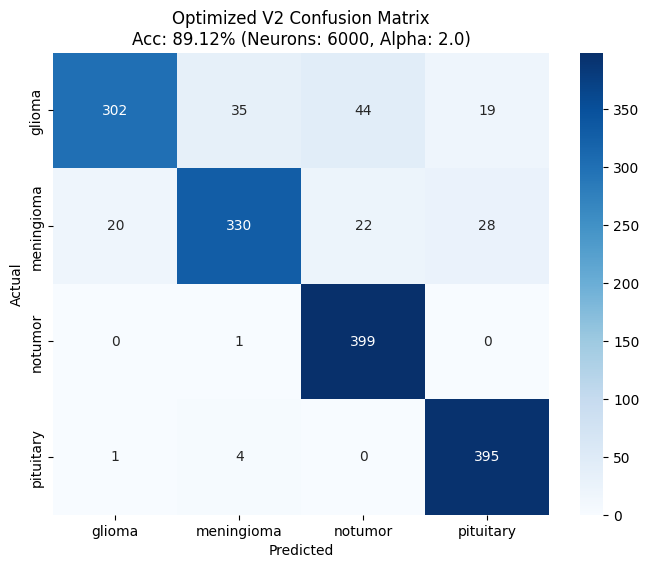

In [11]:
# 🚀 V2.1: Automated Grid Search for RRELM
class RRELM:
    def __init__(self, hidden_neurons=3000, alpha=0.1, random_state=SEED):
        self.hidden_neurons = hidden_neurons
        self.alpha = alpha
        self.random_state = random_state
        self.scaler = MinMaxScaler() 
        self.ridge_classifier = RidgeClassifier(alpha=self.alpha, random_state=self.random_state)
        
    def _relu(self, x):
        return np.maximum(0, x)
        
    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        np.random.seed(self.random_state)
        input_dim = X_scaled.shape[1]
        self.input_weights = np.random.normal(scale=0.1, size=(input_dim, self.hidden_neurons))
        self.biases = np.random.normal(scale=0.1, size=(self.hidden_neurons,))
        H = self._relu(np.dot(X_scaled, self.input_weights) + self.biases)
        self.ridge_classifier.fit(H, y)
        
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        H = self._relu(np.dot(X_scaled, self.input_weights) + self.biases)
        return self.ridge_classifier.predict(H)

print("🔍 Starting Grid Search to find the best RRELM Hyperparameters...")

# التوليفات اللي هنجربها
neurons_options = [2000, 3000, 4000, 5000, 6000]
alpha_options = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

best_val_acc = 0
best_params = {}
best_rrelm_model = None

# اللوب السحري
for n in neurons_options:
    for a in alpha_options:
        temp_model = RRELM(hidden_neurons=n, alpha=a)
        temp_model.fit(X_train_f, y_train_s)
        
        # التقييم على الـ Validation Set الأول عشان نختار أحسن موديل
        val_preds = temp_model.predict(X_val_f)
        val_acc = accuracy_score(y_val_s, val_preds)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = {'neurons': n, 'alpha': a}
            best_rrelm_model = temp_model

print(f"\n✅ Grid Search Complete!")
print(f"🌟 Best Parameters Found -> Neurons: {best_params['neurons']}, Alpha: {best_params['alpha']}")
print(f"🌟 Best Validation Accuracy: {best_val_acc * 100:.2f}%")

# ==========================================
# التقييم النهائي على بيانات الاختبار (Test Data)
# ==========================================
print("\n📊 Evaluating the BEST model on Test Data...")
y_pred_final = best_rrelm_model.predict(X_test_f)
final_test_accuracy = accuracy_score(y_test_s, y_pred_final)

print(f"🔥 Absolute Final Hybrid Test Accuracy: {final_test_accuracy * 100:.2f}%\n")

print("--- Final Classification Report ---")
print(classification_report(y_test_s, y_pred_final, target_names=CLASS_TYPES))

# رسم الـ Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_TYPES, yticklabels=CLASS_TYPES)
plt.title(f'Optimized V2 Confusion Matrix\nAcc: {final_test_accuracy * 100:.2f}% (Neurons: {best_params["neurons"]}, Alpha: {best_params["alpha"]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Generating XAI Heatmap using layer: 'separable_conv2d_3'


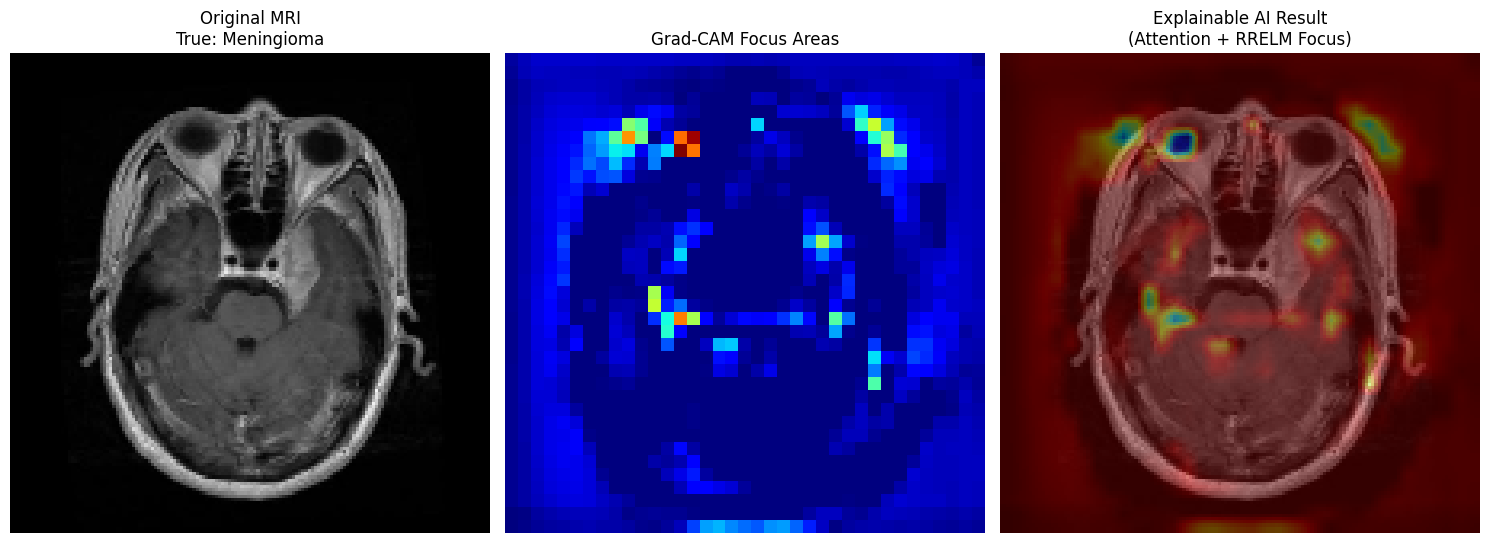

In [12]:
# 🚀 Explainable AI (Grad-CAM)
def get_img_array_with_clahe(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    # تطبيق الـ CLAHE قبل العرض للمطابقة
    img_uint8 = array.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    for i in range(3):
        img_uint8[:,:,i] = clahe.apply(img_uint8[:,:,i])
    
    array = np.expand_dims(img_uint8, axis=0)
    return array.astype(np.float32) / 255.0

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # بدون أقواس لمنع التحذير
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# اختيار طبقة الـ SeparableConv2D للتركيز الدقيق
last_conv_layer_name = None
for layer in reversed(feature_extractor.layers):
    if isinstance(layer, tf.keras.layers.SeparableConv2D):
        last_conv_layer_name = layer.name
        break

print(f"Generating XAI Heatmap using layer: '{last_conv_layer_name}'")

# اختيار صورة عشوائية
random_index = np.random.randint(0, len(test_df))
sample_path = test_df['filepath'].iloc[random_index]
sample_label = test_df['label'].iloc[random_index]

img_array = get_img_array_with_clahe(sample_path, IMAGE_SIZE)
heatmap = make_gradcam_heatmap(img_array, cnn_training_model, last_conv_layer_name)

# تجهيز الصور للعرض
img_disp = cv2.imread(sample_path)
img_disp = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB)
img_disp = cv2.resize(img_disp, IMAGE_SIZE)

heatmap_resized = cv2.resize(heatmap, (img_disp.shape[1], img_disp.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_disp, 0.6, heatmap_colored, 0.4, 0)

# الرسم
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_disp)
plt.title(f"Original MRI\nTrue: {sample_label.title()}", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Focus Areas", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Explainable AI Result\n(Attention + RRELM Focus)", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

Generating XAI Heatmap using layer: 'separable_conv2d_3'


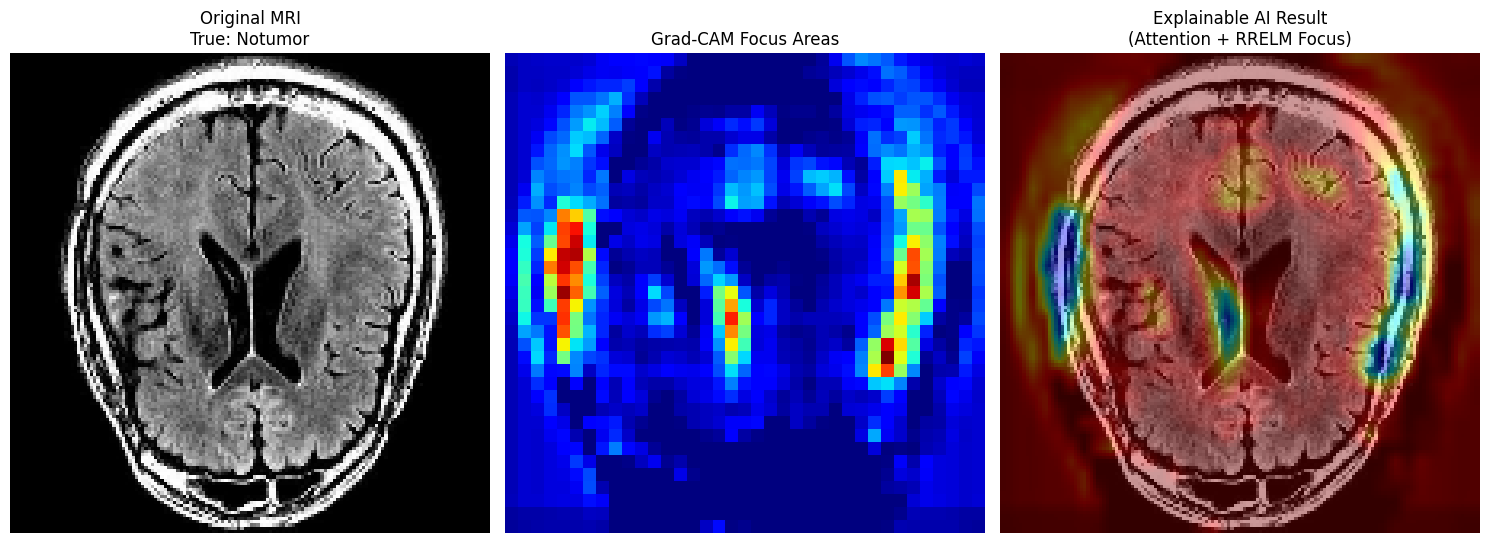

In [13]:
# 🚀 Explainable AI (Grad-CAM)
def get_img_array_with_clahe(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    # تطبيق الـ CLAHE قبل العرض للمطابقة
    img_uint8 = array.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    for i in range(3):
        img_uint8[:,:,i] = clahe.apply(img_uint8[:,:,i])
    
    array = np.expand_dims(img_uint8, axis=0)
    return array.astype(np.float32) / 255.0

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # بدون أقواس لمنع التحذير
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# اختيار طبقة الـ SeparableConv2D للتركيز الدقيق
last_conv_layer_name = None
for layer in reversed(feature_extractor.layers):
    if isinstance(layer, tf.keras.layers.SeparableConv2D):
        last_conv_layer_name = layer.name
        break

print(f"Generating XAI Heatmap using layer: '{last_conv_layer_name}'")

# اختيار صورة عشوائية
random_index = np.random.randint(0, len(test_df))
sample_path = test_df['filepath'].iloc[random_index]
sample_label = test_df['label'].iloc[random_index]

img_array = get_img_array_with_clahe(sample_path, IMAGE_SIZE)
heatmap = make_gradcam_heatmap(img_array, cnn_training_model, last_conv_layer_name)

# تجهيز الصور للعرض
img_disp = cv2.imread(sample_path)
img_disp = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB)
img_disp = cv2.resize(img_disp, IMAGE_SIZE)

heatmap_resized = cv2.resize(heatmap, (img_disp.shape[1], img_disp.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_disp, 0.6, heatmap_colored, 0.4, 0)

# الرسم
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_disp)
plt.title(f"Original MRI\nTrue: {sample_label.title()}", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Focus Areas", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title("Explainable AI Result\n(Attention + RRELM Focus)", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import joblib
import json
import os

print("💾 Saving the entire Hybrid Pipeline...")

# 1. حفظ شبكة استخراج الخصائص (CNN Feature Extractor)
feature_extractor.save('PDSCNN_FeatureExtractor_V2.keras')
print("✅ CNN Feature Extractor saved as 'PDSCNN_FeatureExtractor_V2.keras'")

# 2. حفظ موديل الـ RRELM (بيشمل الـ Scaler وأوزان الـ Ridge)
joblib.dump(best_rrelm_model, 'RRELM_Hybrid_Classifier_V2.pkl')
print("✅ RRELM Classifier & Scaler saved as 'RRELM_Hybrid_Classifier_V2.pkl'")

# 3. حفظ أسماء الكلاسات للترجمة وقت التشغيل
labels_dict = {i: label for i, label in enumerate(CLASS_TYPES)}
with open('class_labels.json', 'w') as f:
    json.dump(labels_dict, f)
print("✅ Class labels saved as 'class_labels.json'")

print("\n🎉 All components saved successfully! You are ready for deployment.")

💾 Saving the entire Hybrid Pipeline...
✅ CNN Feature Extractor saved as 'PDSCNN_FeatureExtractor_V2.keras'
✅ RRELM Classifier & Scaler saved as 'RRELM_Hybrid_Classifier_V2.pkl'
✅ Class labels saved as 'class_labels.json'

🎉 All components saved successfully! You are ready for deployment.


In [16]:
import joblib
import json
import tensorflow as tf

# 1. Load Labels
with open('class_labels.json', 'r') as f:
    labels_dict = json.load(f)

# 2. Load CNN
loaded_cnn = tf.keras.models.load_model('PDSCNN_FeatureExtractor_V2.keras')

# 3. Load RRELM
# (ملحوظة: لازم كود كلاس الـ RRELM اللي كتبناه يكون موجود في نفس ملف بايثون عشان يعرف يقراه)
loaded_rrelm = joblib.load('RRELM_Hybrid_Classifier_V2.pkl')